<a href="https://colab.research.google.com/github/jellyandcream494/dogsandcats/blob/main/dogs_cats_layer1_dropout_0.01_L2_0.0001_earlystopping_batchsize_64.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dog or Cat: Image Classification with CNN
In this example, you will classify whether an image contains either a dog or a cat. The **Dogs vs Cats** dataset was used for a Kaggle machine learning competition held in 2013, back when CNN was not mainstream. The dataset contains 25,000 photos for training (12,500 from each class); and 12,500 unlabeled photos for testing. Unsurprisingly, the dogs-vs-cats Kaggle competition in 2013 was won by entrants who used CNN, achieving up to 95% accuracy.

As a practical example, we will only use a small subset of the dataset containing 2,000 images for training, 1,000 for validation and 1,000 for testing.

In this tutorial, you will learn:
1. how to set up Google Colab.
 * how to access the Google Drive in the Google Colab.
 * how to enable GPU for traing your model
 * how to download dataset from Kaggle directly to Google Drive. (This step is optional—an alternative solution is provided in the comments.)
2. how to train a small ConvNet from scratch, without any regularization. It would set a baseline for what can be achieved.



## Setting-Up 1: Mount Google Drive to the notebook


You can easily load data from Google Drive by mounting it to the notebook. To do this, type the following code in your notebook. Run it, you will see a link, and need enter some code. To get the code, you need first click the link. In the link, after logining to your Google Account, you will see a code. Copy it, and paste it here.

Then you will see "Mounted at /content/drive" -- done!

Now you will see your Google Drive files in the left pane (file explorer). Right click on the file and select 'Copy path'. Your file's full path will be like `/content/gdrive/MyDrive/Colab Notebooks/dogs_vs_cats.ipynb`.

Your current directory will be `/content/`


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## STEP 1: Build the CNN network
Since we only have 2000 images for training, we will use a small convnet with 4 convolutional layers. Here, because you start from inputs of size 150 x 150, you end up with feature maps of size 7 x 7 just before the `Flatten` layer.

Note that the depth of the feature maps progressively increases in the network (from 32 to 128), whereas the size of the feature maps decreases (from 148 x 148 to 7 x 7). This is a pattern you'll see in most CNNs.

Because this is a binary-classficatin problem, you'll end the network with a single neuron (a `Dense` layer of size 1) and a `sigmoid` activation function, which will encode the probability that the network is looking at one class or the other.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

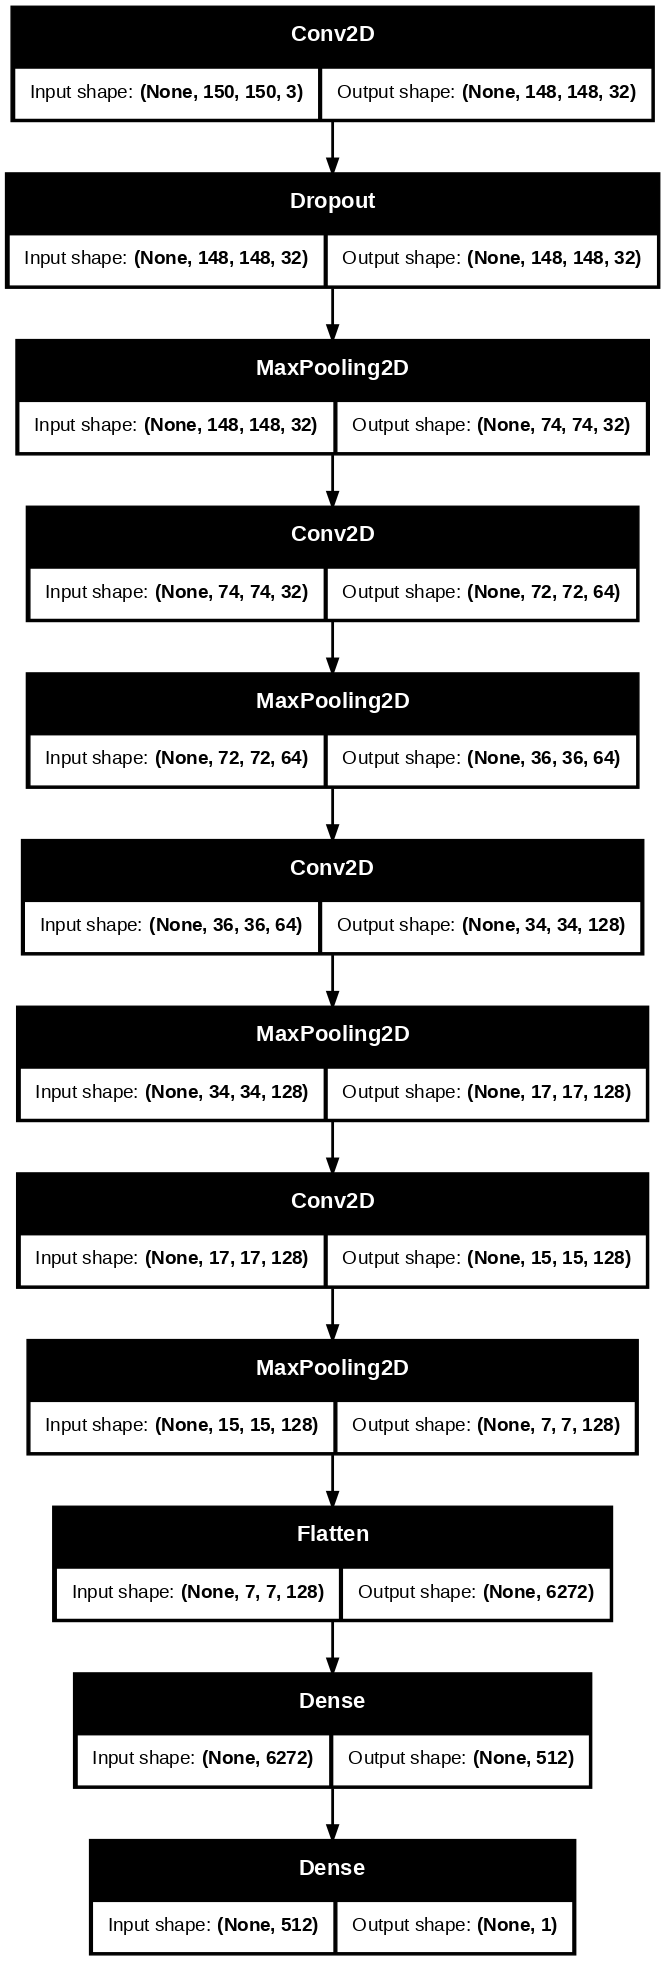

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.regularizers import l2


model = Sequential()

# baseline
# model.add(Input(shape=(150,150,3)))
# model.add(Conv2D(32, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(64, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Flatten())
# model.add(Dense(512, activation='relu'))

# TODO - change architecture/shape and add over/underfitting mitigations

λ = 0.0001


model.add(Input(shape=(150,150,3)))
model.add(Conv2D(32, (3, 3), kernel_regularizer=l2(λ), activation='relu'))
model.add(Dropout(0.01))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, dpi=100) # visualize the CNN artitecture

## STEP 2: Compile the model
The typical loss function for a binary classification problem is the binary cross-entropy loss function.

In [9]:
model.compile(loss='binary_crossentropy',
            optimizer='adam',#adam (with default parameters) is always a good choice
            metrics=['accuracy'])

## STEP 3: Data preprocessing
Now we need do some pre-processing before feeding the data into the network.

Roughly, the preprocessing consists of following steps.
1. Read the image files, decode them to RGB grids of pixels
2. Rescale the pixel values (integers between 0 and 255) to the [0,1] interval, to enhance training stability of neural networks.
3. Apply data augmentation (not covered in this notebook but will be introduced later).

In earlier versions of TensorFlow, `ImageDataGenerator` was commonly used for loading and augmenting image data. However, in the latest versions of TensorFlow, it has been deprecated in favor of the `tf.data` API and Keras preprocessing `keras.layers`. Here’s why:

| Feature | ImageDataGenerator (Deprecated) | tf.data API (Recommended) |
|:--------:|:--------:|:--------:|
|  Performance   |  Slower (Python-based)   |  Faster (TensorFlow-optimized)   |
|  GPU Utilization   |  Limited   |  Efficient prefetching & parallel execution   |
|  Data Augmentation   |  Done in generator   |  Uses built-in Keras layers   |
| Future Support |Deprecated | Actively maintained|

Using `tf.keras.utils.image_dataset_from_directory()` ensures that images are loaded efficiently and processed using the `tf.data` pipeline, which is optimized for TensorFlow training.


In [10]:
import tensorflow as tf

import os
gdrive_dir = '/content/drive/My Drive/MSc_AI/Unit9_ADL'
base_dir = gdrive_dir+'/data/dogs-vs-cats-small'
train_dir = os.path.join(base_dir,'train')
val_dir   = os.path.join(base_dir,'val')
test_dir  = os.path.join(base_dir,'test')

# Define batch size and image size
batch_size = 32
img_size = (150, 150)

# Load the training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size
)

# Load the validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size
)

# Normalize images (rescale pixel values to [0,1])
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Add .cache() to cache the dataset after initial loading and preprocessing
train_dataset = train_dataset.cache()
val_dataset = val_dataset.cache()

# Additional Performance Optimization (Optional)
# Benefit of using AUTOTUNE:
# 1. Loads the next batch while the current batch is being processed
# 2. Reduces data loading bottlenecks
# 3. Improves training speed
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


## STEP 4: Train the model
Now, let's train the CNN model using `model.fit()`. You only need to specify the training and validation datasets, along with the number of epochs.

It is always a good practice to save your model after training to preserve your results.

After training, be sure to plot the loss and accuracy for both the training and validation sets. Visualizing model performance over epochs is crucial for identifying potential overfitting and assessing overall learning progress.

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.5325 - loss: 0.6987 - val_accuracy: 0.5730 - val_loss: 0.6802
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5970 - loss: 0.6649 - val_accuracy: 0.5640 - val_loss: 0.6727
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6465 - loss: 0.6310 - val_accuracy: 0.5620 - val_loss: 0.6776
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6825 - loss: 0.5951 - val_accuracy: 0.6060 - val_loss: 0.6656
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7190 - loss: 0.5553 - val_accuracy: 0.6530 - val_loss: 0.6768
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7400 - loss: 0.5332 - val_accuracy: 0.6120 - val_loss: 0.6979
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7565 - loss: 0.4913 - val_accuracy: 0.6810 - val_loss: 0.6136
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8035 - loss: 0.4348 - val_accuracy: 0.6890 -

Text(0.5, 0, 'epoch')

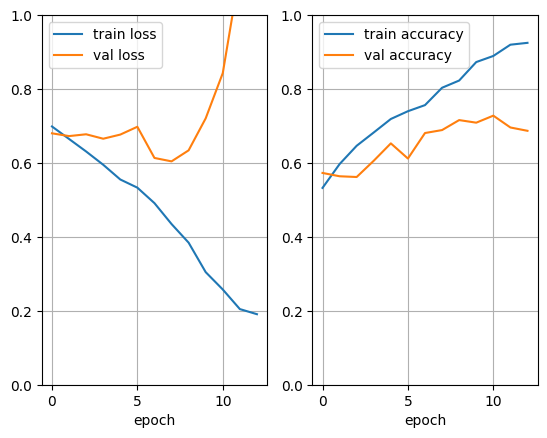

In [11]:
# Train the model

# early stopping
from keras.callbacks import EarlyStopping

es_callback = EarlyStopping( monitor='val_loss',
min_delta = 0.001,
patience=5,
restore_best_weights=True)

epochs = 20
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    callbacks=[es_callback],
    epochs=epochs,
    batch_size=64 # added batch normalisation
)

model_folder = '/content/drive/My Drive/MSc_AI/Unit9_ADL/models'
import os
if not os.path.exists(model_folder):
    os.mkdir(model_folder)
model.save(model_folder+'/dogs_cats_layer1_dropout_0.01_L2_0.0001_earlystopping_batchsize_64.keras')  # always save your model after training

# plot the learning curves
import matplotlib.pyplot as plt
fig = plt.figure()
fig.add_subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

fig.add_subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

The plots shown above exhibit clear signs of overfitting. Notably, the validation loss stopped dropping after around 5 epochs, while the training loss keeps decreasing almost to 0. After 5 epochs, the validation accuracy plateaus at around 71%.

We have only 2000 images for training, while there are 3.45 million parameters in even such a small CNN. Therefore, overfitting is our primary concern. In the upcoming lectures, we will delve into several strategies to mitigate the overfitting problem.

## STEP 5: Evaluate the model on the test set

We first omit this step, since the model we trained is still a baseline. We will investigate how to improve the model later. Then we can evaluate it on the test set.